In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
index_ticket = ["^GSPC", "^IXIC", "^GDAXI", "^FTSE"]

index = yf.download(index_ticket, start="2015-01-01")
stock = yf.download("CAT", start="2015-01-01")

[*********************100%***********************]  4 of 4 completed
[*********************100%***********************]  1 of 1 completed


In [3]:
normalization_index = (index["Close"] / index["Close"].iloc[0] * 100)
print(normalization_index)

Ticker           ^FTSE      ^GDAXI       ^GSPC       ^IXIC
Date                                                      
2015-01-02  100.000000  100.000000  100.000000  100.000000
2015-01-05   98.005443   97.014046   98.172189   98.429380
2015-01-06   97.231134   96.978203   97.299098   97.163630
2015-01-07   98.045145   97.475089   98.430671   98.384961
2015-01-08  100.339048  100.746358  100.191427  100.198440
...                ...         ...         ...         ...
2026-03-09  156.533497  239.733900  330.190963  480.153612
2026-03-10  159.018304  245.461264  329.485965  480.177949
2026-03-11  158.126395  242.096076  329.209988  480.580573
2026-03-12  157.384167  241.580149  324.196884  472.030401
2026-03-13  156.711425  240.122235  322.232538  467.659142

[2891 rows x 4 columns]


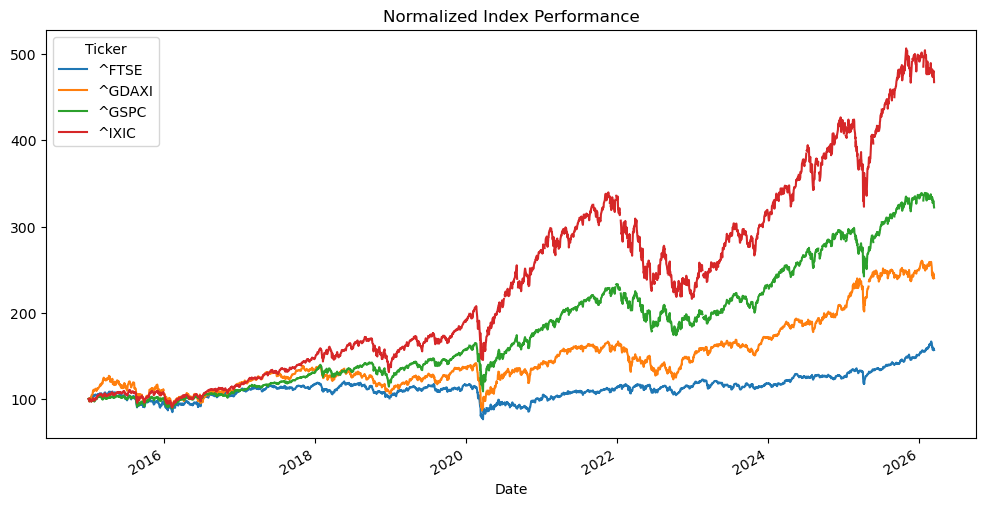

In [4]:
normalization_index.plot(figsize=(12,6))
plt.title("Normalized Index Performance")
plt.show()

In [5]:
index_simple_return = index["Close"] / index["Close"].shift(1) - 1
print(index_simple_return.head(10))

Ticker         ^FTSE    ^GDAXI     ^GSPC     ^IXIC
Date                                              
2015-01-02       NaN       NaN       NaN       NaN
2015-01-05 -0.019946 -0.029860 -0.018278 -0.015706
2015-01-06 -0.007901 -0.000369 -0.008893 -0.012859
2015-01-07  0.008372  0.005124  0.011630  0.012570
2015-01-08  0.023396  0.033560  0.017888  0.018432
2015-01-09 -0.010487 -0.019223 -0.008404 -0.006782
2015-01-12  0.000046  0.013826 -0.008094 -0.008367
2015-01-13  0.006276  0.016265 -0.002579 -0.000688
2015-01-14 -0.023494 -0.012466 -0.005813 -0.004758
2015-01-15  0.017265  0.021955 -0.009248 -0.014765


In [6]:
avg_daily_return = index_simple_return.mean()
print(avg_daily_return)

Ticker
^FTSE     0.000213
^GDAXI    0.000354
^GSPC     0.000531
^IXIC     0.000688
dtype: float64


In [7]:
avg_annual_return = index_simple_return.mean() * 250
print(avg_annual_return)

Ticker
^FTSE     0.053140
^GDAXI    0.088566
^GSPC     0.132691
^IXIC     0.171985
dtype: float64


In [8]:
print(avg_annual_return.sort_values(ascending=False))

Ticker
^IXIC     0.171985
^GSPC     0.132691
^GDAXI    0.088566
^FTSE     0.053140
dtype: float64


In [9]:
stock.head()

Price,Close,High,Low,Open,Volume
Ticker,CAT,CAT,CAT,CAT,CAT
Date,,,,,
2015-01-02,69.158577,69.527407,68.240281,69.075779,3767900
2015-01-05,65.507950,68.059621,65.184286,68.006932,11301400
2015-01-06,65.086433,65.997206,64.107914,65.696123,8660600
2015-01-07,66.095062,66.343456,65.048802,65.763876,6511100
2015-01-08,66.772499,67.201541,66.117643,67.126272,7617800


In [10]:
stock.tail()

Price,Close,High,Low,Open,Volume
Ticker,CAT,CAT,CAT,CAT,CAT
Date,,,,,
2026-03-09,704.820007,708.630005,662.849976,665.219971,3584400
2026-03-10,716.679993,730.789978,710.280029,712.780029,3089100
2026-03-11,707.590027,720.419983,703.630005,713.500000,1947500
2026-03-12,700.690002,703.770020,679.760010,693.000000,3231800
2026-03-13,693.989990,706.928711,687.179993,704.340027,2040681


In [11]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2815 entries, 2015-01-02 to 2026-03-13
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, CAT)   2815 non-null   float64
 1   (High, CAT)    2815 non-null   float64
 2   (Low, CAT)     2815 non-null   float64
 3   (Open, CAT)    2815 non-null   float64
 4   (Volume, CAT)  2815 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 132.0 KB


In [12]:
stock_simple_return = stock["Close"] / stock["Close"].shift(1) - 1
print(stock_simple_return)

Ticker           CAT
Date                
2015-01-02       NaN
2015-01-05 -0.052786
2015-01-06 -0.006435
2015-01-07  0.015497
2015-01-08  0.010249
...              ...
2026-03-09  0.035130
2026-03-10  0.016827
2026-03-11 -0.012683
2026-03-12 -0.009751
2026-03-13 -0.009562

[2815 rows x 1 columns]


In [13]:
avg_daily_return_stock = stock_simple_return.mean()
print(avg_daily_return_stock)

Ticker
CAT    0.001
dtype: float64


In [14]:
avg_annual_return_stock = stock_simple_return.mean() * 250
print(avg_annual_return_stock)

Ticker
CAT    0.250069
dtype: float64


In [15]:
normalization_stock = (stock["Close"] / stock["Close"].iloc[0]*100)

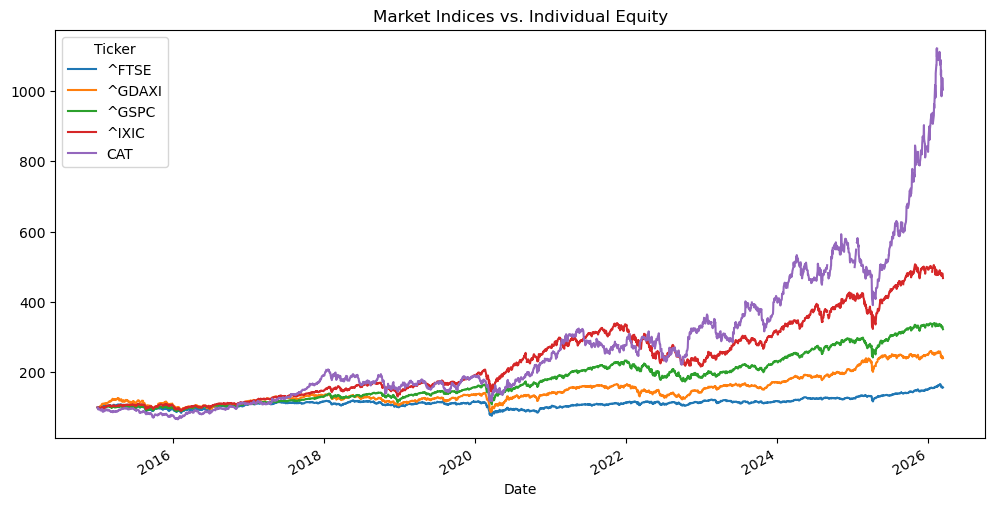

In [16]:
combined = pd.concat([normalization_index,normalization_stock] ,axis=1)
combined.plot(figsize=(12,6))
plt.title("Market Indices vs. Individual Equity")
plt.show()

# Caterpillar (CAT) has consistently outperformed the broader market indices. Notably, it has generated significant alpha relative to the S&P 500 since 2020, demonstrating strong relative strength and superior momentum against the benchmark through 2023.

# Addressing the ultimate investment question—security selection—requires careful consideration. Based on our comparative analysis, Caterpillar (CAT) emerges as a highly promising equity, exhibiting robust upside potential and attractive historical returns. However, a comprehensive recommendation cannot rely solely on absolute returns; risk-adjusted performance metrics (such as volatility and maximum drawdown) must be thoroughly evaluated to reach a definitive conclusion.

# In conclusion, while investing in a broad market index inherently provides diversification and lower volatility (risk) compared to individual equities, it also yields correspondingly lower expected returns. Ultimately, the optimal capital allocation depends entirely on the individual investor's risk tolerance, investment horizon, and broader portfolio strategy.